Import libraries

In [4]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

First, we need to import the kaggle dataset into this jupyter notebook. This code snippet is taken straight from kaggle.

In [5]:
# Set the path to the file you'd like to load
file_path = "wildfire_events.csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "meruvakodandasuraj/global-wildfire-intelligence-20012026",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

Now it's time to try and understand the data within the context of the question I am trying to answer. I looked through each of the columns to see what data they hold and what datatype they have. This helped me to narrow down which columns I may need for my prediction model.

In [6]:
df.shape

(9277, 39)

In [7]:
df.head

<bound method NDFrame.head of        event_id        date  year  month  day_of_year  season region_id  \
0     WF0000001  2001-02-01  2001      2           32  Summer   aus_nsw   
1     WF0000002  2001-02-13  2001      2           44  Summer   aus_nsw   
2     WF0000003  2001-12-18  2001     12          352  Summer   aus_nsw   
3     WF0000004  2001-11-22  2001     11          326  Autumn   aus_nsw   
4     WF0000005  2001-12-01  2001     12          335  Summer   aus_nsw   
...         ...         ...   ...    ...          ...     ...       ...   
9272  WF0009273  2026-12-02  2026     12          336  Summer   nam_osh   
9273  WF0009274  2026-12-02  2026     12          336  Summer   nam_osh   
9274  WF0009275  2026-12-24  2026     12          358  Summer   nam_osh   
9275  WF0009276  2026-12-27  2026     12          361  Summer   nam_osh   
9276  WF0009277  2026-11-13  2026     11          317  Autumn   nam_osh   

          region_name    country continent  ...  relative_humidity_pc

In [8]:
col_names = df.columns
col_names

Index(['event_id', 'date', 'year', 'month', 'day_of_year', 'season',
       'region_id', 'region_name', 'country', 'continent', 'latitude',
       'longitude', 'climate_zone', 'vegetation_type',
       'fire_radiative_power_mw', 'burn_area_hectares', 'burn_area_km2',
       'severity', 'fire_duration_days', 'contained', 'human_caused',
       'detection_satellite', 'detection_confidence', 'co2_emissions_tonnes',
       'pm25_emissions_tonnes', 'pm10_emissions_tonnes', 'co_emissions_tonnes',
       'ch4_emissions_tonnes', 'air_temp_celsius', 'relative_humidity_pct',
       'wind_speed_kmh', 'wind_direction', 'drought_index',
       'structures_threatened', 'structures_destroyed', 'evacuation_orders',
       'people_evacuated', 'enso_phase', 'climate_anomaly_year'],
      dtype='str')

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9277 entries, 0 to 9276
Data columns (total 39 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   event_id                 9277 non-null   str    
 1   date                     9277 non-null   str    
 2   year                     9277 non-null   int64  
 3   month                    9277 non-null   int64  
 4   day_of_year              9277 non-null   int64  
 5   season                   9277 non-null   str    
 6   region_id                9277 non-null   str    
 7   region_name              9277 non-null   str    
 8   country                  9277 non-null   str    
 9   continent                9277 non-null   str    
 10  latitude                 9277 non-null   float64
 11  longitude                9277 non-null   float64
 12  climate_zone             9277 non-null   str    
 13  vegetation_type          9277 non-null   str    
 14  fire_radiative_power_mw  9277 non-n

The 'human_caused' column is the final product that we're trying to predict. I wanted to make it clearer what 0 and 1 meant in the this column so used hot-one encoding to give them string values for 'human' or 'lightning' caused. The dataset info on kaggle specifies that these are the two possible values in the column.

In [10]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df['climate_zone_encoded'] = label_encoder.fit_transform(df['climate_zone'])
df['human_caused_encoded'] = df['human_caused'].replace(1, "Human caused").replace(0, "Lighning caused")

df['human_caused_encoded']

0          Human caused
1       Lighning caused
2       Lighning caused
3       Lighning caused
4       Lighning caused
             ...       
9272       Human caused
9273       Human caused
9274    Lighning caused
9275    Lighning caused
9276       Human caused
Name: human_caused_encoded, Length: 9277, dtype: object

Now it's time to do some analysis on the data. I created this bar chart to get an idea of the distributon on wildfire causes. It seems that human caused fires outweigh those caused by lightning. After a bit of research into model training, I found that I'll need to leave out some rows in the training data to make it a more even split so that the model can't just have a 'lucky guess'.

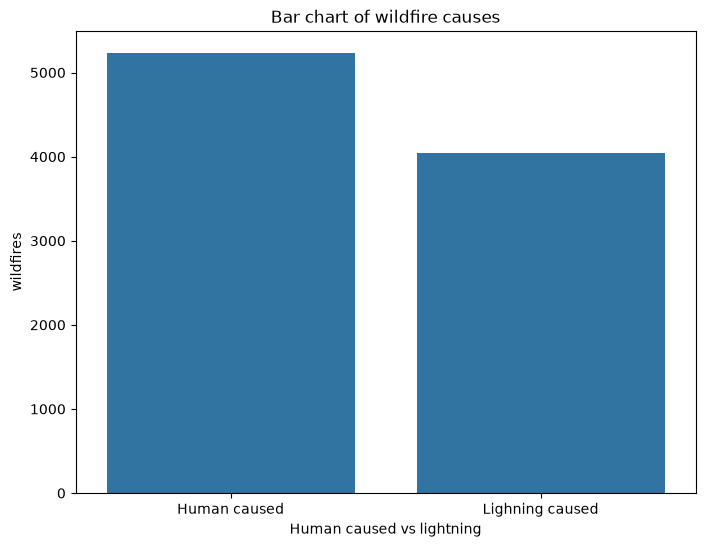

In [11]:
fig, ax = plt.subplots(figsize=(8,6))

with plt.style.context('default'):

    sns.countplot(x="human_caused_encoded", data=df)
    ax.set(xlabel="Human caused vs lightning", ylabel="wildfires", title="Bar chart of wildfire causes")

plt.show()

Now to get an idea of the spread of causes by country. This count plot shows me that there are some countries (eg. Russia) where there are much more human caused wildfires in the dataset, and some (eg. Italy) where there is a more even split. This is useful to note, as including the country label in the prediction model's training data could cause it to heavily favour the 'human caused' output just because it shows up more in the data. This would be an example of overfitting the data, something I'll need to be precautious about.

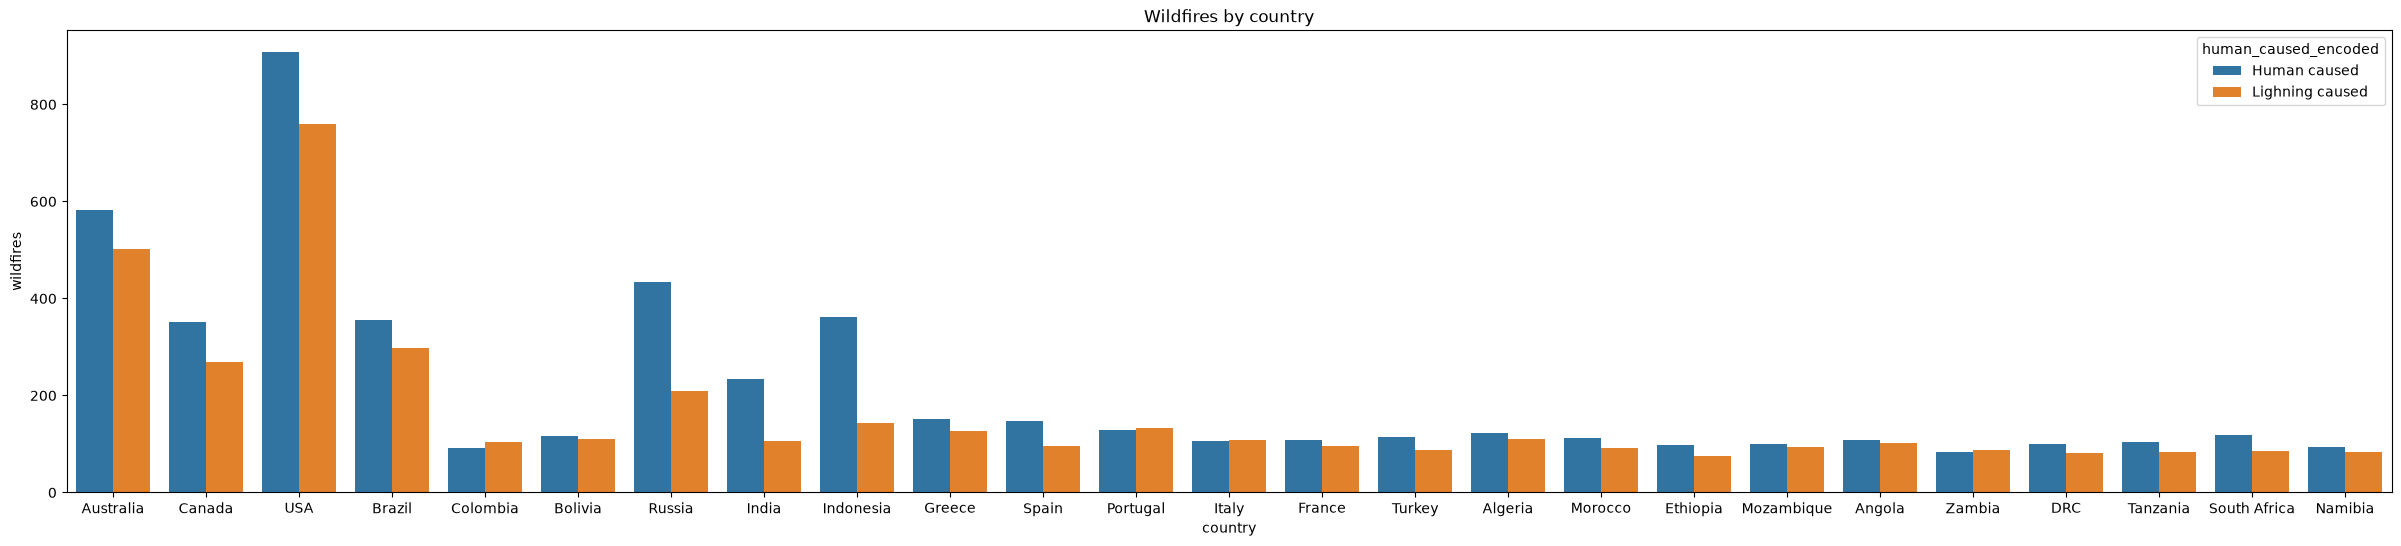

In [12]:
with plt.style.context('default'):
    fig, ax = plt.subplots(figsize=(30,6))

    sns.countplot(x=df['country'], hue="human_caused_encoded", data=df)
    ax.set(xlabel="country", ylabel="wildfires", title="Wildfires by country")

plt.show()

I wanted to see if there was any point including the country as well as the climate zone in my training data. The fact that there are many countries with only one climate zone could suggest that it would be pointless including both. Given that human-caused wildfires are over represented by certain countries in the dataset and that climate zone will be more helpful for prediction anyway, I will probably only use the climate zone column in the training data. 

On another note, a bar chart definitely isn't the best way to lay out this data.

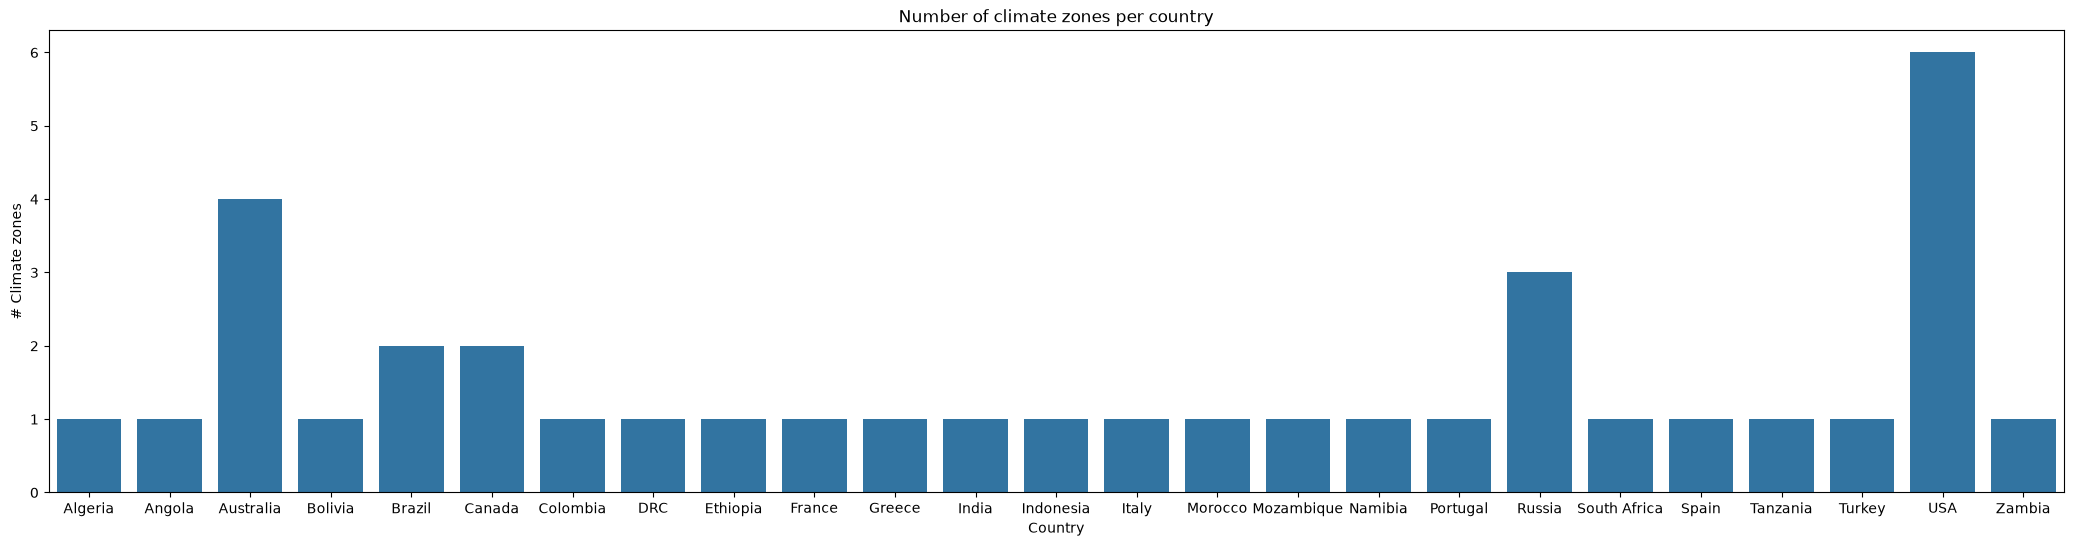

In [13]:
unique_countries = df['country'].unique

country_climate_zones = df.groupby('country')['climate_zone'].nunique()

# num_of_climate_zones = country_climate_zones.
# print(num_of_climate_zones)

with plt.style.context('default'):
    fig, ax = plt.subplots(figsize=(26,6))

    sns.barplot(x=country_climate_zones.index, y=country_climate_zones.values)

    ax.set(xlabel="Country", ylabel="# Climate zones", title="Number of climate zones per country")
plt.show()

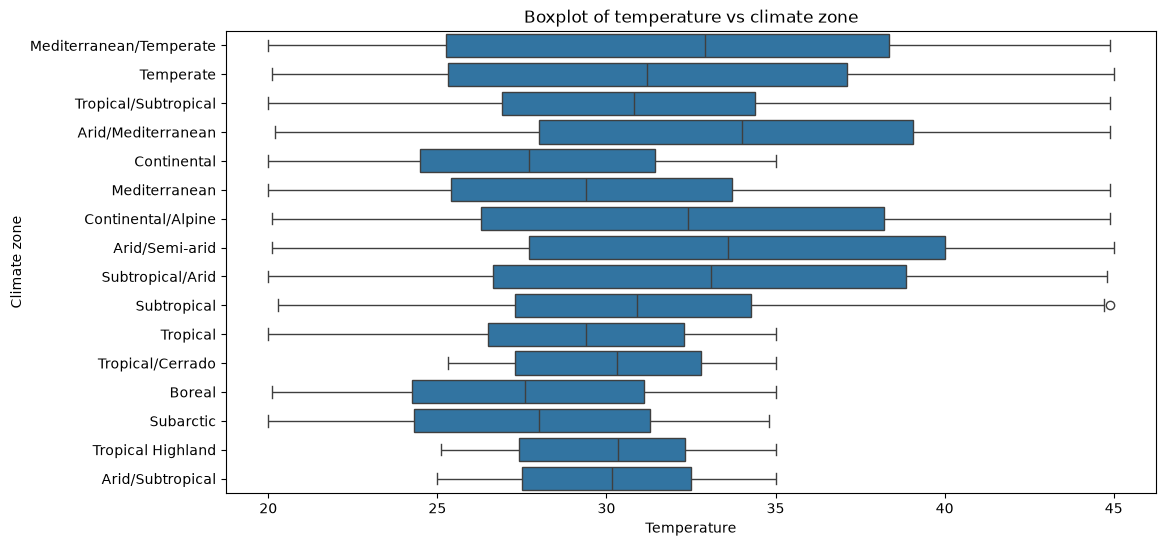

In [14]:
climate_zones = df['climate_zone'].unique()

with plt.style.context('default'):
    fig, ax = plt.subplots(figsize=(12,6))


    sns.boxplot(x="air_temp_celsius", y="climate_zone", data=df, ax=ax)
    ax.set(xlabel="Temperature", ylabel="Climate zone", title="Boxplot of temperature vs climate zone")
plt.show()

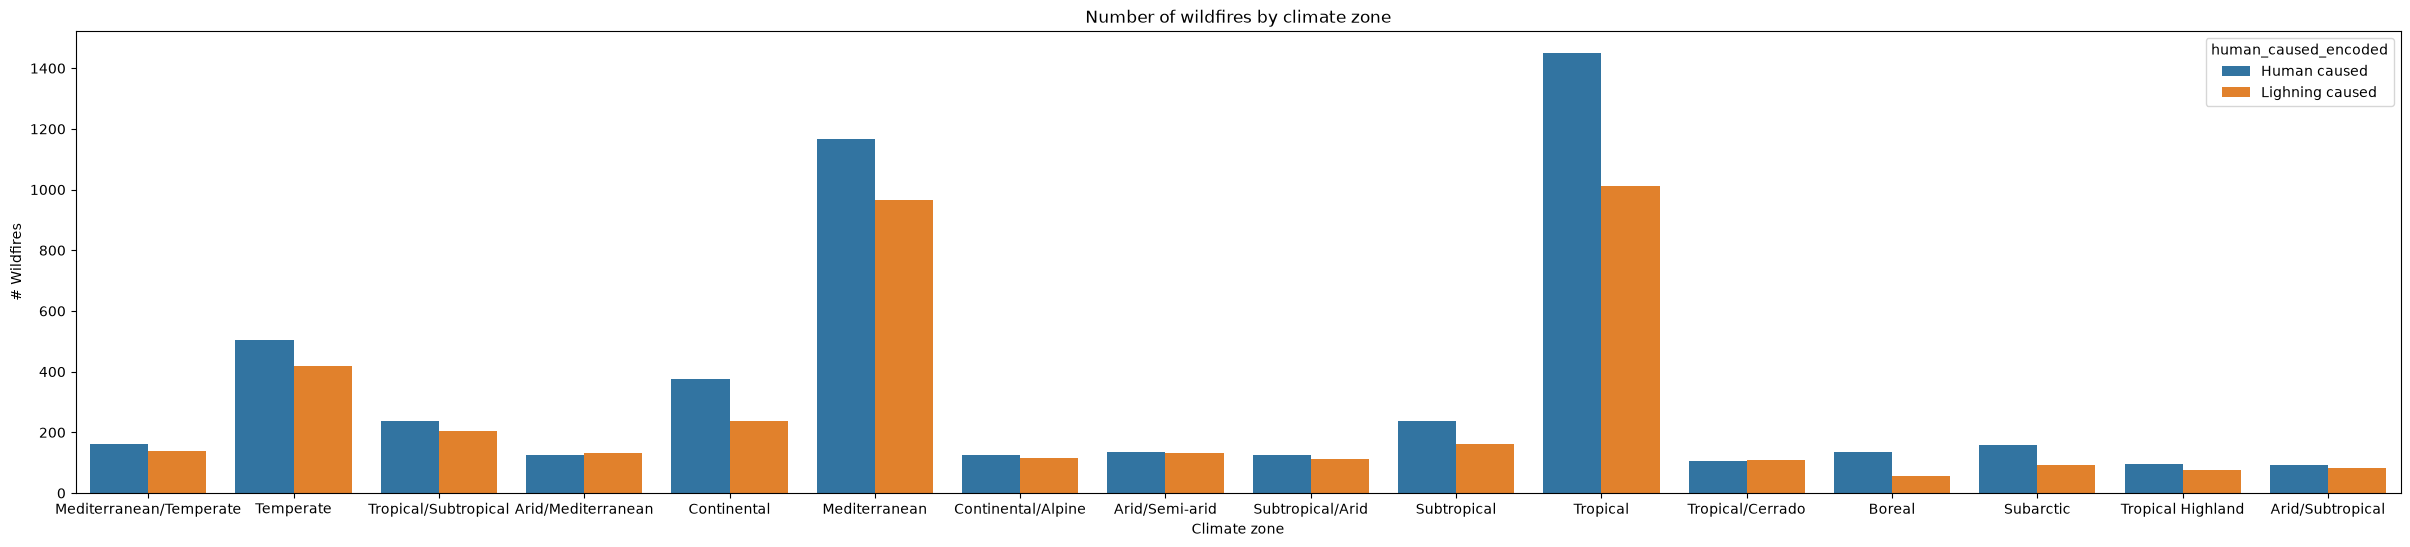

In [15]:
with plt.style.context('default'):
    fig, ax = plt.subplots(figsize=(30,6))

    sns.countplot(x='climate_zone', data=df, hue='human_caused_encoded')
    ax.set(xlabel="Climate zone", ylabel="# Wildfires", title="Number of wildfires by climate zone")

plt.show()

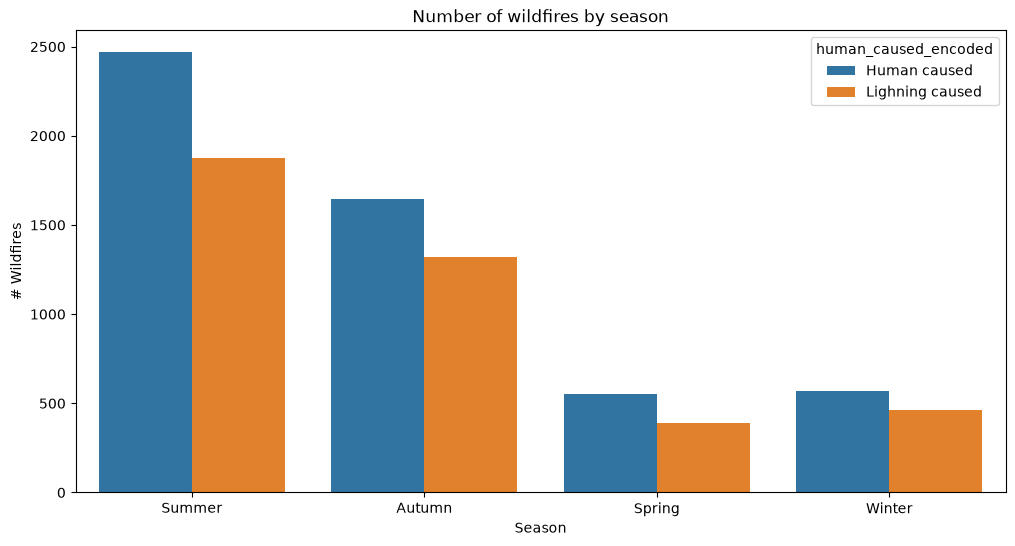

In [16]:
human_caused_df = df[df['human_caused'] == 1]

with plt.style.context('default'):
    fig, ax = plt.subplots(figsize=(12,6))

    sns.countplot(x='season', data=df, hue='human_caused_encoded')
    ax.set(xlabel="Season", ylabel="# Wildfires", title="Number of wildfires by season")

plt.show()

I want to see if there is a strong correlation between three data points: drought index, relative humidity and temperature. I hypothesise that there is, given that (with some research) I found that drought index is heavily based on humidity and temperature.

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[ 0.,-0.]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['air_temp_celsius','relative_humidity_pct']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.5425
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)


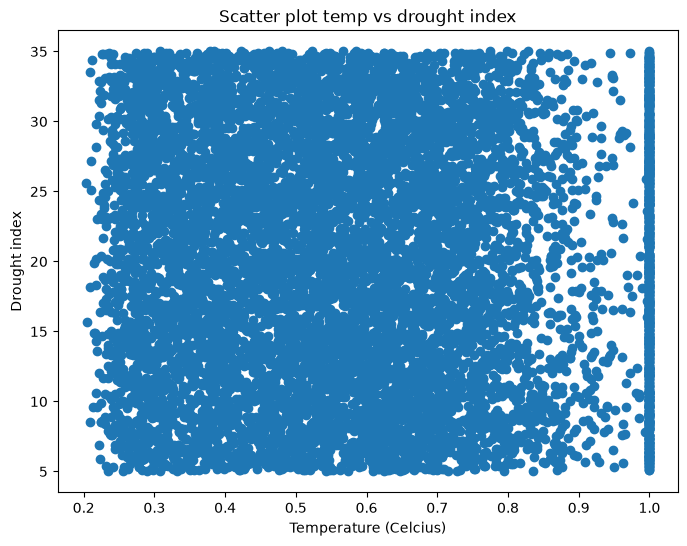

In [17]:
#air_temp_celsius
#relative_humidity_pct
#drought_index

with plt.style.context('default'):
    fig,ax = plt.subplots(figsize=(8,6))

    ax.scatter(x=df['drought_index'], y=df['relative_humidity_pct'])

    ax.set(xlabel="Temperature (Celcius)", ylabel="Drought index", title="Scatter plot temp vs drought index")

from sklearn import linear_model

reg = linear_model.LinearRegression()
reg.fit(df[['air_temp_celsius', 'relative_humidity_pct']], df['drought_index'])

In [18]:
# sns.pairplot(df)

# plt.show()

In [19]:
null_count = df.isnull().sum()

# print(null_count)

At this point I want to have an initial attempt at training, just to see what happens. The data points I will use are: Season, climate zone, temperature, humidity, wind speed, drought index, vegetation type. 

I will now encode these columns into number values

In [20]:
categorical_cols = ['season', 'climate_zone', 'vegetation_type']
encoder = OneHotEncoder(sparse_output=False) 

encoded_cols = encoder.fit_transform(df[categorical_cols])

encoded_df = pd.DataFrame(encoded_cols, columns=encoder.get_feature_names_out(input_features=categorical_cols))
print(encoded_df)

      season_Autumn  season_Spring  season_Summer  season_Winter  \
0               0.0            0.0            1.0            0.0   
1               0.0            0.0            1.0            0.0   
2               0.0            0.0            1.0            0.0   
3               1.0            0.0            0.0            0.0   
4               0.0            0.0            1.0            0.0   
...             ...            ...            ...            ...   
9272            0.0            0.0            1.0            0.0   
9273            0.0            0.0            1.0            0.0   
9274            0.0            0.0            1.0            0.0   
9275            0.0            0.0            1.0            0.0   
9276            1.0            0.0            0.0            0.0   

      climate_zone_Arid/Mediterranean  climate_zone_Arid/Semi-arid  \
0                                 0.0                          0.0   
1                                 0.0      

Now we want to vertically concatenate our encoded_df (all the columns requiring one hot encoding) to the feature_columns that don't require encoding.

In [21]:
feature_columns = df[['air_temp_celsius', 'relative_humidity_pct', 'wind_speed_kmh', 'drought_index', 'human_caused']]
# print(feature_columns.head)

final_df = pd.concat([encoded_df, feature_columns], axis=1)

# print(final_df.head)
# print(final_df['season_Autumn'].isna().sum())
print(final_df.iloc[0])

season_Autumn                            0.000
season_Spring                            0.000
season_Summer                            1.000
season_Winter                            0.000
climate_zone_Arid/Mediterranean          0.000
climate_zone_Arid/Semi-arid              0.000
climate_zone_Arid/Subtropical            0.000
climate_zone_Boreal                      0.000
climate_zone_Continental                 0.000
climate_zone_Continental/Alpine          0.000
climate_zone_Mediterranean               0.000
climate_zone_Mediterranean/Temperate     1.000
climate_zone_Subarctic                   0.000
climate_zone_Subtropical                 0.000
climate_zone_Subtropical/Arid            0.000
climate_zone_Temperate                   0.000
climate_zone_Tropical                    0.000
climate_zone_Tropical Highland           0.000
climate_zone_Tropical/Cerrado            0.000
climate_zone_Tropical/Subtropical        0.000
vegetation_type_Boreal Forest            0.000
vegetation_ty

Now I am going to split up our final dataframe into X (the variables the model can use to predict) and y (the binary value it is trying to predict)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X = final_df.drop('human_caused', axis=1)
y = final_df['human_caused']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

clf = LogisticRegression(max_iter=1000, random_state=0)
clf.fit(X_train, y_train)

acc = accuracy_score(y_test, clf.predict(X_test)) * 100
print(f"Logistic Regression model accuracy: {acc:.2f}%")


Logistic Regression model accuracy: 54.58%


/home/ekinge/Documents/Programming/Machine Learning/ml-env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
